# Customer 360 View
## Project Execution Guidelines

### Step 1: Data Loading and Initial Exploration

* Load all datasets using Pandas
* Inspect structure using `.head()`, `.info()`, `.describe()`
* Identify primary and foreign keys
* Understand relationships between tables

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
#!pip install pathlib
from pathlib import Path
current_dir = Path.cwd()
data_folder = current_dir/"python_project_aiml_logicmojo_dataset"
#print(data_folder)
data_files = glob.glob(f"{data_folder}/*.csv")
dataframes = {}
#Load all datasets using Pandas
for file_path_str in data_files:
    file_path = Path(file_path_str)
    #print(file_path)
    key = file_path.stem
    try:
        dataframes[key] = pd.read_csv(file_path)
        # Inspect structure using
        print(f"\nFirst {key} 3 rows:")
        print(dataframes[key].head(3))
        print(f"\nInformation about {key}:")
        print(dataframes[key].info())
        print(f"\nInformation about {key} Shape:")
        print(dataframes[key].shape)
        print(f"\n {key} Summary Statistics:")
        print(dataframes[key].describe())
        print(f"\n  {key} Missing Values:")
        print(dataframes[key].isnull().sum())
        print(f"\n  {key} Duplicate Values:")
        print(dataframes[key].duplicated().sum())
        
    except Exception as e:
        print(f"Failed to load {var_name} : {e}")


First customers 3 rows:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  

Information about customers:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3

In [35]:
print(list(dataframes.keys()))

['customers', 'products', 'reviews', 'orders', 'category_translation', 'location', 'payments', 'sellers', 'order_item']


In [36]:
all_column_lists = []
for df in dataframes.values():
    all_column_lists.append(list(df.columns))
#print(all_column_lists)
all_column_sets = []
for col_list in all_column_lists:
    all_column_sets.append(set(col_list))
print(all_column_sets)

[{'customer_unique_id', 'customer_city', 'customer_id', 'customer_state', 'customer_zip_code_prefix'}, {'product_name_lenght', 'product_height_cm', 'product_width_cm', 'product_length_cm', 'product_weight_g', 'product_id', 'product_description_lenght', 'product_photos_qty', 'product_category_name'}, {'review_creation_date', 'review_comment_title', 'review_answer_timestamp', 'order_id', 'review_id', 'review_score', 'review_comment_message'}, {'order_delivered_carrier_date', 'customer_id', 'order_id', 'order_delivered_customer_date', 'order_approved_at', 'order_purchase_timestamp', 'order_status', 'order_estimated_delivery_date'}, {'product_category_name_english', 'product_category_name'}, {'geolocation_zip_code_prefix', 'geolocation_state', 'geolocation_lng', 'geolocation_lat', 'geolocation_city'}, {'payment_type', 'payment_sequential', 'order_id', 'payment_installments', 'payment_value'}, {'seller_zip_code_prefix', 'seller_state', 'seller_city', 'seller_id'}, {'order_item_id', 'freight

In [37]:
# Manually assigning each table to its own explicit variable
customers            = dataframes['customers'].copy()
products             = dataframes['products'].copy()
reviews              = dataframes['reviews'].copy()
orders               = dataframes['orders'].copy()
category_translation = dataframes['category_translation'].copy()
location             = dataframes['location'].copy()
payments             = dataframes['payments'].copy()
sellers              = dataframes['sellers'].copy()
order_item           = dataframes['order_item'].copy()


### Visualising the Data

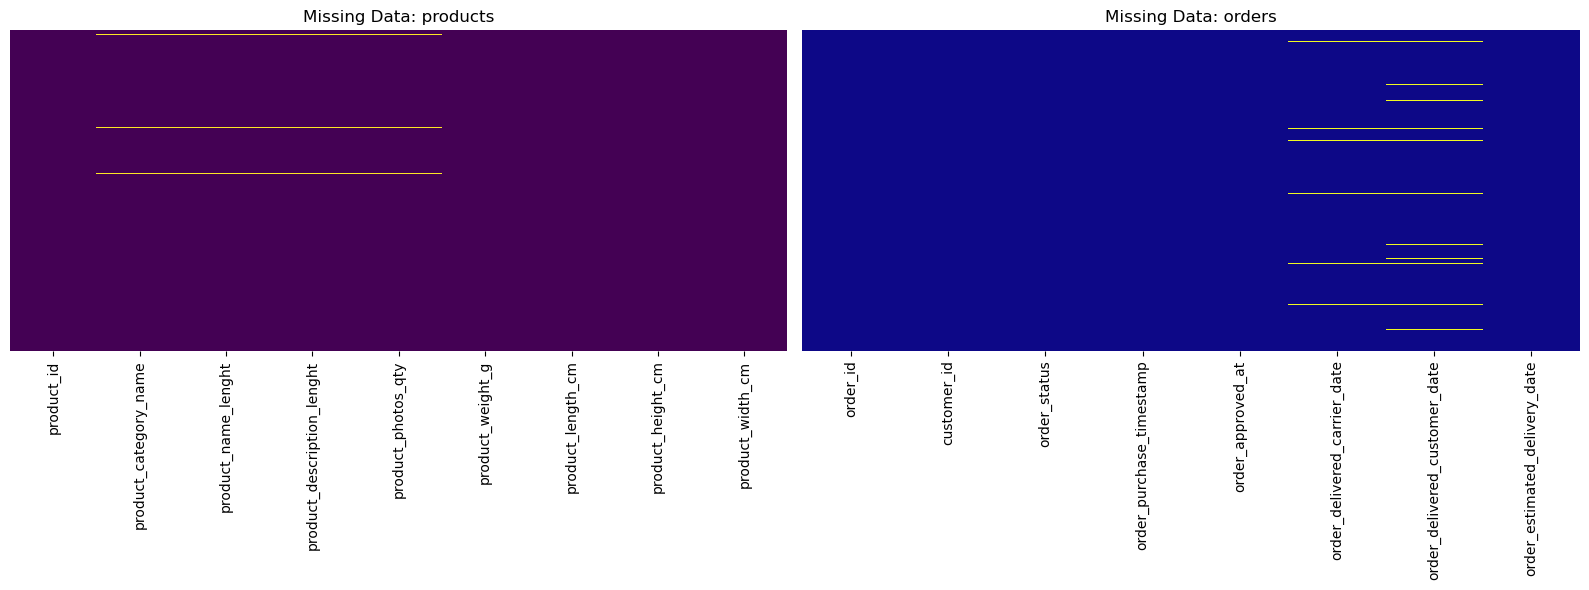

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Products nulls
sns.heatmap(products.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=axes[0])
axes[0].set_title("Missing Data: products")

# Right plot: Orders nulls
sns.heatmap(orders.isnull(), cbar=False, yticklabels=False, cmap='plasma', ax=axes[1])
axes[1].set_title("Missing Data: orders")

plt.tight_layout()
plt.show()

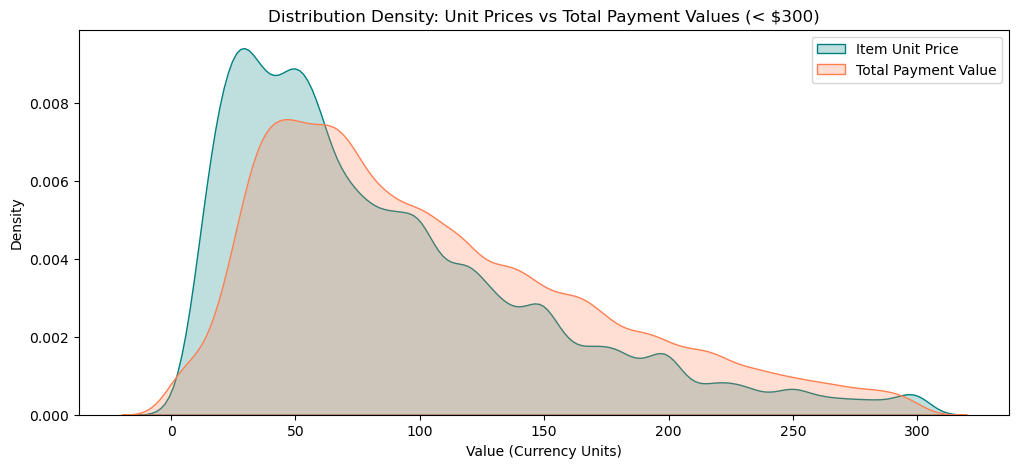

In [39]:
plt.figure(figsize=(12, 5))

# Plotting item prices under $300 to cut out long-tail outliers for cleaner visualization
sns.kdeplot(data=order_item[order_item['price'] < 300], x='price', fill=True, label='Item Unit Price', color='teal')
sns.kdeplot(data=payments[payments['payment_value'] < 300], x='payment_value', fill=True, label='Total Payment Value', color='coral')

plt.title("Distribution Density: Unit Prices vs Total Payment Values (< $300)")
plt.xlabel("Value (Currency Units)")
plt.ylabel("Density")
plt.legend()
plt.show()

/var/folders/tj/lqgl8v6x1lzf043mjmcl6tp80000gn/T/ipykernel_24784/3684893422.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customers, x='customer_state', order=state_order, palette='Blues_r')


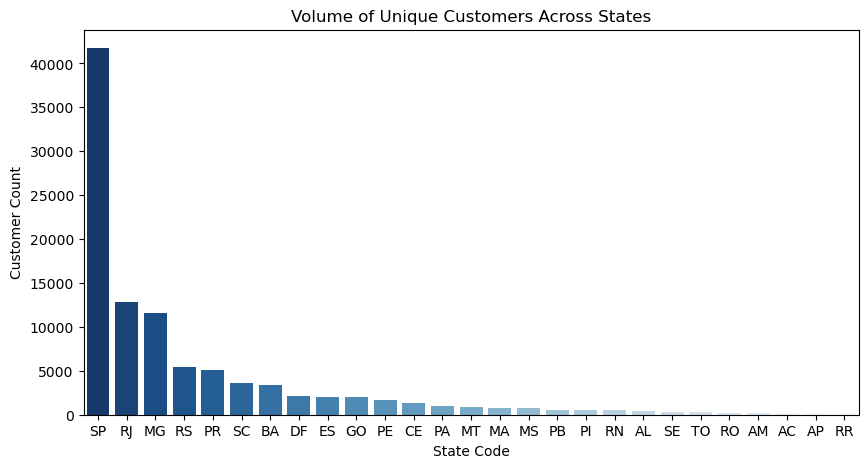

In [40]:
plt.figure(figsize=(10, 5))

# Order states from highest volume to lowest
state_order = customers['customer_state'].value_counts().index

# Using a standard, built-in Seaborn palette name ('Blues_r' for reversed blue gradient)
sns.countplot(data=customers, x='customer_state', order=state_order, palette='Blues_r')

plt.title("Volume of Unique Customers Across States")
plt.xlabel("State Code")
plt.ylabel("Customer Count")
plt.show()

### Step 2: Data Cleaning and Preprocessing

* Handle missing values appropriately
* Remove duplicate records
* Convert date columns to datetime format
* Validate data types and ranges
* Standardize column names if required

In [41]:
df_to_clean = {
    'customers': customers, 'products': products, 'reviews': reviews, 
    'orders': orders, 'category_translation': category_translation, 
    'location': location, 'payments': payments, 'sellers': sellers, 
    'order_item': order_item
}
#Making sure column names are consistent
for name, df in df_to_clean.items():
    df.columns.str.strip().str.lower().str.replace(' ', '_')

In [42]:
#Remove duplicate records
for name, df in df_to_clean.items():
    initial_shape = df.shape
    dupli = df.duplicated().sum()
    if dupli > 0:
        df.drop_duplicates(inplace=True)
        print(f"{name}: Removed {dupli} duplicates. Old Shape {initial_shape}, new shape {df.shape}")
    else:
        print(f"{name}: Zero duplicates found. Shape {df.shape}")


customers: Zero duplicates found. Shape (99441, 5)
products: Zero duplicates found. Shape (32951, 9)
reviews: Zero duplicates found. Shape (99224, 7)
orders: Zero duplicates found. Shape (99441, 8)
category_translation: Zero duplicates found. Shape (71, 2)
location: Removed 261831 duplicates. Old Shape (1000163, 5), new shape (738332, 5)
payments: Zero duplicates found. Shape (103886, 5)
sellers: Zero duplicates found. Shape (3095, 4)
order_item: Zero duplicates found. Shape (112650, 7)


In [45]:
#Fix the date format
#Reviews Table
df_to_clean['reviews']['review_creation_date'] = pd.to_datetime(df_to_clean['reviews']['review_creation_date'],errors='coerce')
df_to_clean['reviews']['review_answer_timestamp'] = pd.to_datetime(df_to_clean['reviews']['review_creation_date'],errors='coerce')
#Order Table
df_to_clean['orders']['order_purchase_timestamp'] = pd.to_datetime(df_to_clean['reviews']['review_creation_date'],errors='coerce')
df_to_clean['orders']['order_approved_at'] = pd.to_datetime(df_to_clean['reviews']['review_creation_date'],errors='coerce')
df_to_clean['orders']['order_delivered_carrier_date'] = pd.to_datetime(df_to_clean['reviews']['review_creation_date'],errors='coerce')
df_to_clean['orders']['order_delivered_customer_date'] = pd.to_datetime(df_to_clean['reviews']['review_creation_date'],errors='coerce')
df_to_clean['orders']['order_estimated_delivery_date'] = pd.to_datetime(df_to_clean['reviews']['review_creation_date'],errors='coerce')
#Order Item Table
df_to_clean['order_item']['shipping_limit_date'] = pd.to_datetime(df_to_clean['reviews']['review_creation_date'],errors='coerce')

Missing values - 
Random Missing - Manageable
Pattern Suspecious
Few rows - Drop them
Missing column - fill it up
Text comment keep NAN
Critical numeric - impute some values.
Drop - Drop NA
Fill - Fill NA
Isnull - check missing data.
Duplicate Records - Show detection - Show fixing step - Verification step
(add inline comments)
Date converstion - To Datetime - Show with info (Verify)
Datatype - numberic, string, object - Correct data type- .info 
Column Standardisation- Lower case with underscore
data quality report

In [ ]:
#Handle missing data
products['product_category_name'] = (
    products['product_category_name']
    .fillna('unknown')
)



### Step 3: Data Integration (Critical Component)

You must construct a **Master Dataset** by merging multiple tables.

Recommended sequence:

1. orders + customers
2. orders + order_items
3. order_items + products
4. orders + payments
5. orders + reviews
6. order_items + sellers
7. products + category_translation

**Final output:** A **single consolidated dataset** representing a unified business view

Data integration - Building customer 360

Customer system
Order system
product system
Payment system
Review System

One review everything about customer + order + product + payments + reviews

### Step 4: Feature Engineering

Create meaningful features such as:

* Total order value (aggregated from order_items or payments)
* Delivery time (order purchase to delivery date)
* Number of items per order
* Customer purchase frequency
* Customer lifetime value (basic approximation)
* Average order value per customer

### Step 5: Exploratory Data Analysis (EDA)

Perform structured analysis across the following dimensions:

#### Customer Analysis

* New vs repeat customers
* High-value vs low-value customers
* Geographic distribution of customers

#### Revenue and Order Analysis

* Monthly revenue trends
* Order volume trends
* Peak sales periods

#### Product Analysis

* Top-selling product categories
* Revenue contribution by category
* Product demand distribution

#### Seller Analysis

* Top-performing sellers
* Seller contribution to revenue
* Seller distribution

#### Review and Satisfaction Analysis

* Distribution of review scores
* Relationship between delivery time and ratings
* Identification of dissatisfaction patterns

### Step 6: Data Visualization

Use Matplotlib and Seaborn to create:

* Time series plots (sales trends)
* Bar charts (category performance)
* Histograms (distribution analysis)
* Box plots (outlier detection)
* Heatmaps (correlation analysis)

All visualizations must be clearly labeled and interpretable.

### Step 7: Business Insights and Recommendations

You must derive clear and actionable insights:

* Identify top revenue-driving factors
* Highlight customer behavior patterns
* Evaluate operational inefficiencies
* Provide strategic recommendations

Insights must be supported by data and visual evidence.